# Notebook 3 — LSTM Baseline: Brain Network Activation Prediction

**Goal:** Train an LSTM to predict the next activation state (7 Yeo networks) given a 20-TR temporal window.

**Input data:**
- `X.npy` → shape `(115115, 20, 7)` — temporal windows
- `y.npy` → shape `(115115, 7)` — binary target (next TR)
- `sample_metadata.csv` — per-sample metadata (subject, session, etc.)
- `OASIS3_metadata_clean.csv` — clinical metadata (DEMENTED, NORMCOG, Age)

**Notebook structure:**
1. Data loading and clinical metadata
2. Subject-level split (train/val/test) stratified by clinical group
3. LSTM model definition
4. Training with loss and metric monitoring
5. Evaluation: loss curves, accuracy, confusion matrices per network
6. Clinical group analysis (DEMENTED vs NORMCOG)

## 1. Imports and configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    hamming_loss
)
from sklearn.model_selection import train_test_split

from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 34
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

# ── Network names ──────────────────────────────────────────────────────────
NETWORK_NAMES = [
    'Visual',
    'Somatomotor',
    'Dorsal_Attention',
    'Ventral_Attention',
    'Limbic',
    'Frontoparietal',
    'Default_Mode'
]
N_NETWORKS = len(NETWORK_NAMES)

Using device: cuda


## 2. Data loading

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_DIR   = Path('model_dataset_Z15_W20')   # carpeta generada en notebook 2
METADATA_PATH = Path('OASIS3_metadata_clean.csv')

# ── Load arrays ──────────────────────────────────────────────────────────────
X_all        = np.load(DATASET_DIR / 'X.npy')                    # (N, 20, 7)
y_all        = np.load(DATASET_DIR / 'y.npy')                    # (N, 7)
sample_meta  = pd.read_csv(DATASET_DIR / 'sample_metadata.csv')  # (N, 9)
clinical     = pd.read_csv(METADATA_PATH)                        # metadatos clínicos

print(f'X shape : {X_all.shape}')
print(f'y shape : {y_all.shape}')
print(f'Muestras: {len(sample_meta)}')
print()
print('Clinical metadata:')
print(clinical.head())
print(f'\nClinical distribution:')
print(clinical[['DEMENTED', 'NORMCOG']].value_counts())

X shape : (115115, 20, 7)
y shape : (115115, 7)
Muestras: 115115

Clinical metadata:
  Subject_ID Session_ID  DEMENTED  NORMCOG    Age
0   OAS30001      d0129         0        1  65.54
1   OAS30002      d0653         0        1  69.04
2   OAS30003      d0558         0        1  60.34
3   OAS30004      d1101         0        1  58.14
4   OAS30005      d0581         0        1  49.65

Clinical distribution:
DEMENTED  NORMCOG
0         1          686
1         0          400
Name: count, dtype: int64


In [3]:
# ── Merge clinical metadata into each sample ────────────────────────────────────
# Normalizar IDs para el merge
clinical['subject'] = 'sub-' + clinical['Subject_ID'].astype(str)

sample_meta = sample_meta.merge(
    clinical[['subject', 'DEMENTED', 'NORMCOG', 'Age']],
    on='subject',
    how='left'
)

# Create readable group column
sample_meta['group'] = 'Unknown'
sample_meta.loc[sample_meta['DEMENTED'] == 1, 'group'] = 'Demented'
sample_meta.loc[sample_meta['NORMCOG']  == 1, 'group'] = 'NormCog'

print('Sample distribution by group:')
print(sample_meta['group'].value_counts())
print(f"\nSamples without assigned group: {(sample_meta['group'] == 'Unknown').sum()}")

Sample distribution by group:
group
NormCog     73691
Demented    41424
Name: count, dtype: int64

Samples without assigned group: 0


## 3. Subject-level split (no data leakage)

**IMPORTANT:** The split is done at subject level, not sample level.
All TRs from the same subject go to the same split.

In [4]:
subject_groups = (
    sample_meta[['subject', 'group']]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(f'Unique subjects: {len(subject_groups)}')
print(subject_groups['group'].value_counts())

# ── Sequential Split: 70% train / 15% val / 15% test ────────────────────────
subjects_list = subject_groups['subject'].tolist()
n_subjects = len(subjects_list)

# Calculamos los puntos de corte exactos según el orden de la lista
train_end = int(n_subjects * 0.70)          # Fin del 70%
val_end = int(n_subjects * 0.85)            # Fin del 85% (70% + 15%)

# Hacemos slices secuenciales
train_subjects = subjects_list[:train_end]
val_subjects   = subjects_list[train_end:val_end]
test_subjects  = subjects_list[val_end:]

print(f'\nSubjects in train : {len(train_subjects)}')
print(f'Subjects in val   : {len(val_subjects)}')
print(f'Subjects in test  : {len(test_subjects)}')

# ── Sample indices per split ─────────────────────────────────────────────────
train_idx = sample_meta[sample_meta['subject'].isin(train_subjects)].index.values
val_idx   = sample_meta[sample_meta['subject'].isin(val_subjects)].index.values
test_idx  = sample_meta[sample_meta['subject'].isin(test_subjects)].index.values

print(f'\nSamples in train : {len(train_idx)}')
print(f'Samples in val   : {len(val_idx)}')
print(f'Samples in test  : {len(test_idx)}')

# Verify no overlap between splits
assert len(set(train_idx) & set(val_idx))  == 0, 'LEAK train-val!'
assert len(set(train_idx) & set(test_idx)) == 0, 'LEAK train-test!'
assert len(set(val_idx)   & set(test_idx)) == 0, 'LEAK val-test!'
print('\n✓ No data leakage between splits')

Unique subjects: 1080
group
NormCog     680
Demented    400
Name: count, dtype: int64

Subjects in train : 756
Subjects in val   : 162
Subjects in test  : 162

Samples in train : 79622
Samples in val   : 17510
Samples in test  : 17983

✓ No data leakage between splits


## 4. Dataset and DataLoaders

In [5]:
class BrainWindowDataset(Dataset):
    """
    Dataset PyTorch para ventanas temporales de activación binaria.
    
    Parámetros
    ----------
    X : np.ndarray  shape (N, window_size, n_networks)
    y : np.ndarray  shape (N, n_networks)
    indices : np.ndarray  índices de las muestras a incluir
    """
    def __init__(self, X, y, indices):
        self.X = torch.tensor(X[indices], dtype=torch.float32)
        self.y = torch.tensor(y[indices], dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


BATCH_SIZE = 512

train_dataset = BrainWindowDataset(X_all, y_all, train_idx)
val_dataset   = BrainWindowDataset(X_all, y_all, val_idx)
test_dataset  = BrainWindowDataset(X_all, y_all, test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')

Train batches: 156
Val batches  : 35
Test batches : 36


## 5. LSTM Model

In [6]:
class BrainLSTM(nn.Module):
    """
    LSTM para predicción multiclase de activación de redes cerebrales.

    Arquitectura:
        Input  → LSTM (n_layers) → Dropout → Linear → Sigmoid

    Parámetros
    ----------
    input_size  : int   número de redes (7)
    hidden_size : int   dimensión del estado oculto
    n_layers    : int   capas LSTM apiladas
    dropout     : float dropout entre capas LSTM (sólo si n_layers > 1)
    output_size : int   número de redes a predecir (7)
    """
    def __init__(
        self,
        input_size  = 7,
        hidden_size = 64,
        n_layers    = 2,
        dropout     = 0.3,
        output_size = 7
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.n_layers    = n_layers

        # LSTM principal
        self.lstm = nn.LSTM(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = n_layers,
            batch_first = True,
            dropout     = dropout if n_layers > 1 else 0.0
        )

        # Capa de salida
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        lstm_out, _ = self.lstm(x)          # (batch, seq_len, hidden_size)
        last_hidden = lstm_out[:, -1, :]    # last time step
        out = self.dropout(last_hidden)
        out = self.fc(out)                  # (batch, output_size)
        return out                          # logits — sigmoid is applied inside the loss


# ── Instantiate model ─────────────────────────────────────────────────────────
model = BrainLSTM(
    input_size  = N_NETWORKS,
    hidden_size = 64,
    n_layers    = 2,
    dropout     = 0.3,
    output_size = N_NETWORKS
).to(DEVICE)

print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nParámetros entrenables: {total_params:,}')

BrainLSTM(
  (lstm): LSTM(7, 64, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=7, bias=True)
)

Parámetros entrenables: 52,423


## 6. Training

In [7]:
# ── Pos weight for class imbalance ──────────────────────────────────────
# Compute how much the positive class weighs (activación=1) en cada red
y_train = y_all[train_idx]
pos_freq = y_train.mean(axis=0)                        # fracción de 1s por red
neg_freq = 1 - pos_freq
pos_weight = torch.tensor(
    neg_freq / (pos_freq + 1e-8),
    dtype=torch.float32
).to(DEVICE)

print('Positive weight per network (pos_weight):')
for name, w in zip(NETWORK_NAMES, pos_weight.cpu().numpy()):
    print(f'  {name:<22}: {w:.2f}')

# ── Loss, optimizer and scheduler ────────────────────────────────────────────
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

Positive weight per network (pos_weight):
  Visual                : 14.78
  Somatomotor           : 12.53
  Dorsal_Attention      : 13.10
  Ventral_Attention     : 13.35
  Limbic                : 14.80
  Frontoparietal        : 13.59
  Default_Mode          : 13.59


In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Run one training epoch. Returns average loss."""
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()

        # Gradient clipping for stability
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        total_loss += loss.item() * len(X_batch)

    return total_loss / len(loader.dataset)


@torch.no_grad()
def eval_epoch(model, loader, criterion, device):
    """Evaluate the model. Returns loss, hamming_acc, and predictions."""
    model.eval()
    total_loss = 0.0
    all_probs  = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        total_loss += loss.item() * len(X_batch)

        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(y_batch.cpu().numpy())

    all_probs  = np.concatenate(all_probs,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    avg_loss = total_loss / len(loader.dataset)

    # Hamming accuracy with threshold=0.5
    preds       = (all_probs >= 0.5).astype(int)
    hamming_acc = 1 - hamming_loss(all_labels, preds)

    return avg_loss, hamming_acc, all_probs, all_labels


# ── Training loop ────────────────────────────────────────────────────
N_EPOCHS     = 30
best_val_loss = np.inf
best_model_path = Path('best_lstm_model.pt')

history = defaultdict(list)

print(f'Training {N_EPOCHS} epochs on {DEVICE}...\n')

for epoch in tqdm(range(1, N_EPOCHS + 1), desc='Epochs'):

    train_loss = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_hacc, _, _ = eval_epoch(model, val_loader, criterion, DEVICE)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_hacc'].append(val_hacc)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), best_model_path)
        tag = ' ← best'
    else:
        tag = ''

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | '
              f'Train loss: {train_loss:.4f} | '
              f'Val loss  : {val_loss:.4f} | '
              f'Hamming acc val: {val_hacc:.4f}{tag}')

print(f'\nEntrenamiento completado. Mejor val_loss: {best_val_loss:.4f}')

Training 30 epochs on cuda...



Epochs:   0%|          | 0/30 [00:00<?, ?it/s]

Epoch   1/30 | Train loss: 1.2099 | Val loss  : 1.0439 | Hamming acc val: 0.8057 ← best
Epoch   5/30 | Train loss: 0.9963 | Val loss  : 0.9688 | Hamming acc val: 0.8657
Epoch  10/30 | Train loss: 0.9855 | Val loss  : 0.9621 | Hamming acc val: 0.8836
Epoch  15/30 | Train loss: 0.9811 | Val loss  : 0.9559 | Hamming acc val: 0.8698 ← best
Epoch  20/30 | Train loss: 0.9759 | Val loss  : 0.9555 | Hamming acc val: 0.8782 ← best
Epoch  25/30 | Train loss: 0.9748 | Val loss  : 0.9540 | Hamming acc val: 0.8762 ← best
Epoch  30/30 | Train loss: 0.9730 | Val loss  : 0.9537 | Hamming acc val: 0.8743 ← best

Entrenamiento completado. Mejor val_loss: 0.9537


## 7. Training curves

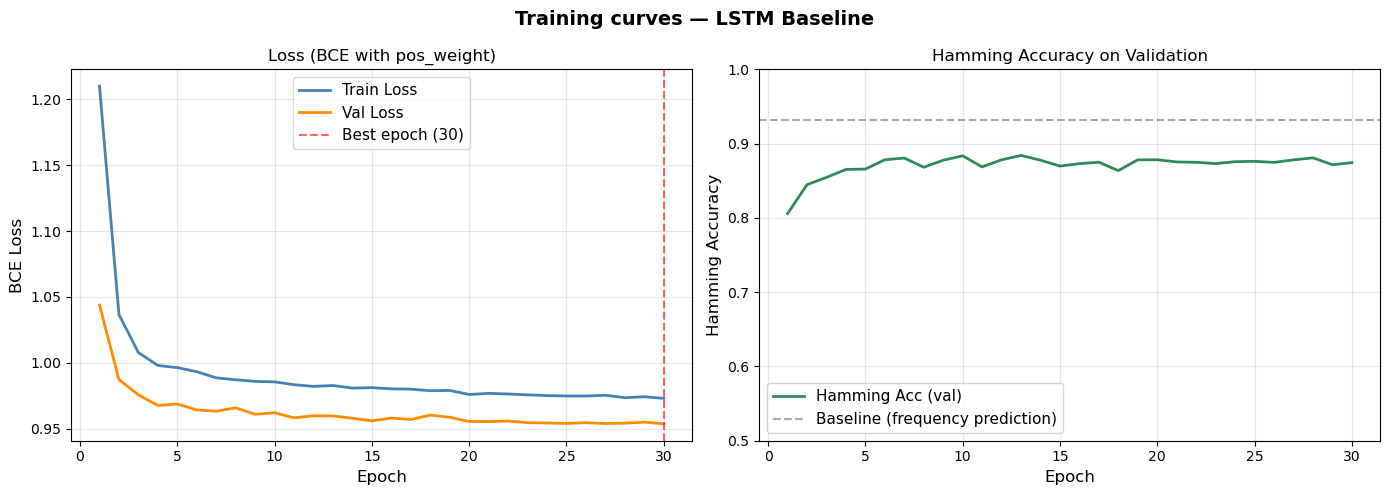

Figure saved: curves_training.png


In [9]:
epochs = range(1, N_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training curves — LSTM Baseline', fontsize=14, fontweight='bold')

# ── Loss ──────────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(epochs, history['train_loss'], label='Train Loss', color='steelblue',  linewidth=2)
ax.plot(epochs, history['val_loss'],   label='Val Loss',   color='darkorange', linewidth=2)
best_epoch = int(np.argmin(history['val_loss'])) + 1
ax.axvline(best_epoch, color='red', linestyle='--', alpha=0.6, label=f'Best epoch ({best_epoch})')
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('BCE Loss', fontsize=12)
ax.set_title('Loss (BCE with pos_weight)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

# ── Hamming Accuracy ──────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(epochs, history['val_hacc'], label='Hamming Acc (val)', color='seagreen', linewidth=2)
ax.axhline(
    y=1 - hamming_loss(
        y_all[val_idx],
        np.tile(y_all[train_idx].mean(axis=0) > 0.5, (len(val_idx), 1))
    ),
    color='gray', linestyle='--', alpha=0.7, label='Baseline (frequency prediction)'
)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Hamming Accuracy', fontsize=12)
ax.set_title('Hamming Accuracy on Validation', fontsize=12)
ax.set_ylim([0.5, 1.0])
ax.legend(fontsize=11)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('Figure saved: curves_training.png')

## 8. Test evaluation

In [10]:
# ── Load best model ───────────────────────────────────────────────────────
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
print('Best model loaded.\n')

# ── Evaluate on test ───────────────────────────────────────────────────────────
test_loss, test_hacc, test_probs, test_labels = eval_epoch(
    model, test_loader, criterion, DEVICE
)
test_preds = (test_probs >= 0.5).astype(int)

print(f'Test Loss          : {test_loss:.4f}')
print(f'Test Hamming Acc   : {test_hacc:.4f}')

# ── Per-network metrics ──────────────────────────────────────────────────────────
print('\n── Métricas por red ──')
metrics_per_net = []
for i, name in enumerate(NETWORK_NAMES):
    auroc  = roc_auc_score(test_labels[:, i], test_probs[:, i])
    auprc  = average_precision_score(test_labels[:, i], test_probs[:, i])
    freq   = test_labels[:, i].mean()
    metrics_per_net.append({'Red': name, 'AUROC': auroc, 'AUPRC': auprc, 'Freq. activación': freq})
    print(f'  {name:<22} | AUROC: {auroc:.3f} | AUPRC: {auprc:.3f} | Freq: {freq:.3f}')

metrics_df = pd.DataFrame(metrics_per_net)
print(f'\nAUROC medio : {metrics_df["AUROC"].mean():.3f}')
print(f'AUPRC medio : {metrics_df["AUPRC"].mean():.3f}')

Best model loaded.

Test Loss          : 0.8957
Test Hamming Acc   : 0.8819

── Métricas por red ──
  Visual                 | AUROC: 0.827 | AUPRC: 0.424 | Freq: 0.063
  Somatomotor            | AUROC: 0.825 | AUPRC: 0.453 | Freq: 0.075
  Dorsal_Attention       | AUROC: 0.840 | AUPRC: 0.465 | Freq: 0.071
  Ventral_Attention      | AUROC: 0.817 | AUPRC: 0.427 | Freq: 0.072
  Limbic                 | AUROC: 0.803 | AUPRC: 0.359 | Freq: 0.062
  Frontoparietal         | AUROC: 0.817 | AUPRC: 0.423 | Freq: 0.068
  Default_Mode           | AUROC: 0.829 | AUPRC: 0.426 | Freq: 0.065

AUROC medio : 0.822
AUPRC medio : 0.425


## 9. Confusion matrices per network

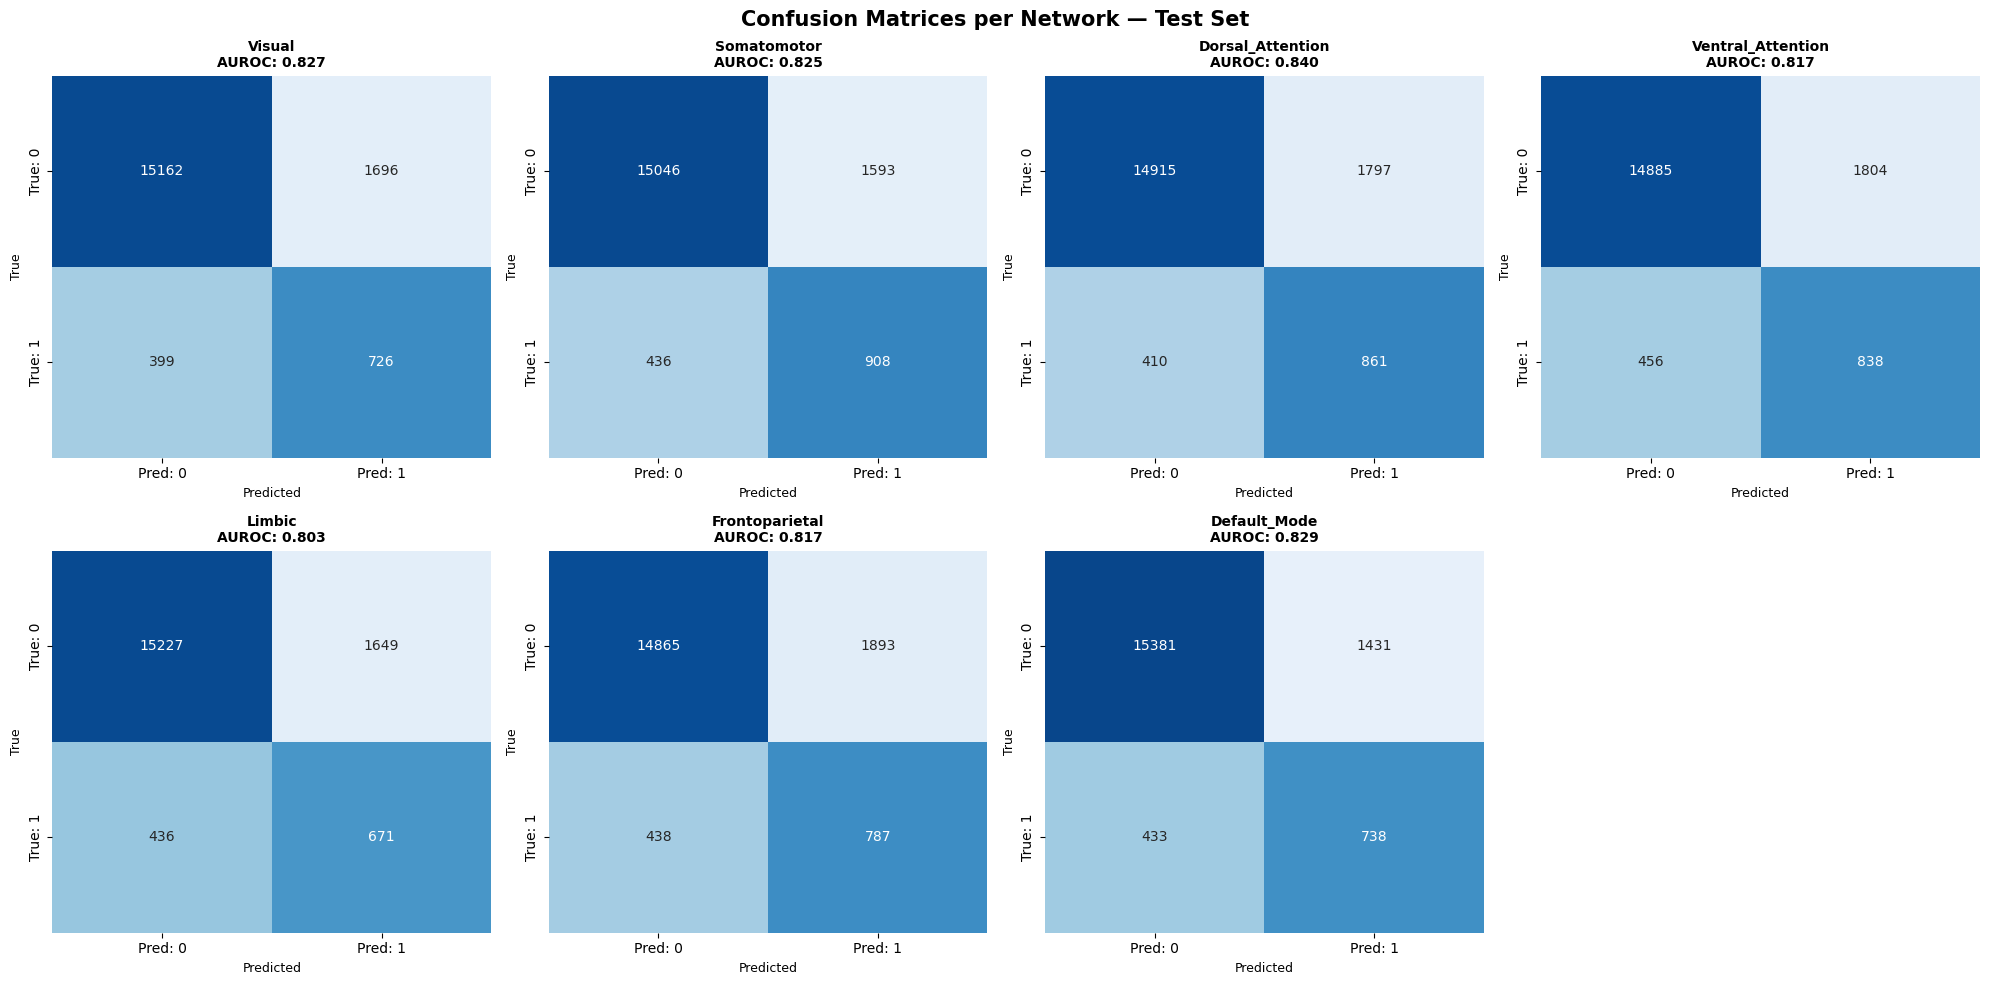

Figure saved: confusion_matrices.png


In [11]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Confusion Matrices per Network — Test Set', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, name in enumerate(NETWORK_NAMES):
    cm = confusion_matrix(test_labels[:, i], test_preds[:, i])

    # Normalize by row (recall)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    ax = axes[i]
    sns.heatmap(
        cm_norm,
        annot=cm,           # show real counts
        fmt='d',
        cmap='Blues',
        vmin=0, vmax=1,
        ax=ax,
        cbar=False,
        xticklabels=['Pred: 0', 'Pred: 1'],
        yticklabels=['True: 0', 'True: 1']
    )
    auroc = metrics_df.loc[metrics_df['Red'] == name, 'AUROC'].values[0]
    ax.set_title(f'{name}\nAUROC: {auroc:.3f}', fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=9)
    ax.set_ylabel('True', fontsize=9)

# Hide the extra subplot (tenemos 7 redes en grid 2x4)
axes[7].set_visible(False)

plt.tight_layout()
plt.show()
print('Figure saved: confusion_matrices.png')

## 10. AUROC and AUPRC per network (bar plot)

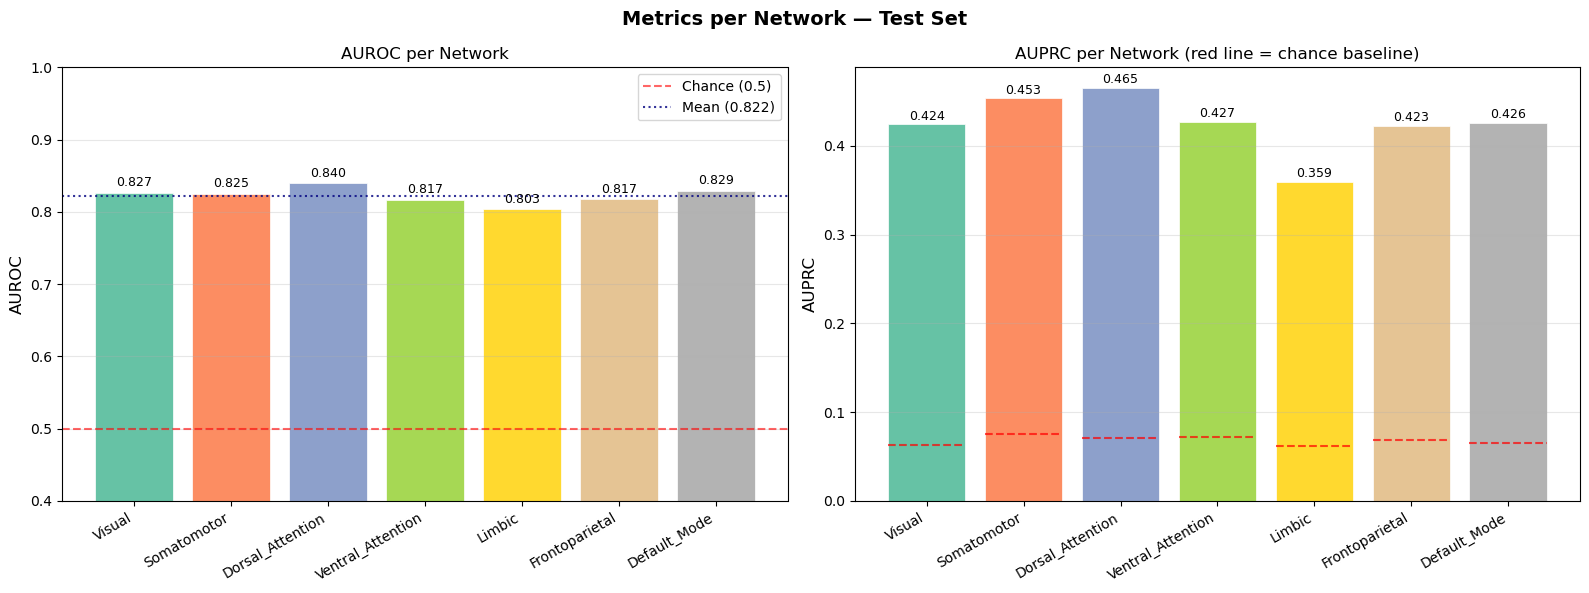

Figure saved: metrics_per_network.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Metrics per Network — Test Set', fontsize=14, fontweight='bold')

colors = plt.cm.Set2(np.linspace(0, 1, N_NETWORKS))
x      = np.arange(N_NETWORKS)

# ── AUROC ─────────────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(x, metrics_df['AUROC'], color=colors, edgecolor='white', linewidth=0.5)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.6, label='Chance (0.5)')
ax.axhline(metrics_df['AUROC'].mean(), color='navy', linestyle=':', alpha=0.8,
           label=f'Mean ({metrics_df["AUROC"].mean():.3f})')
ax.set_xticks(x)
ax.set_xticklabels(NETWORK_NAMES, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('AUROC', fontsize=12)
ax.set_title('AUROC per Network', fontsize=12)
ax.set_ylim([0.4, 1.0])
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, metrics_df['AUROC']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# ── AUPRC ─────────────────────────────────────────────────────────────────────
ax = axes[1]
bars = ax.bar(x, metrics_df['AUPRC'], color=colors, edgecolor='white', linewidth=0.5)
# Baseline AUPRC = positive class frequency
for j, row in metrics_df.iterrows():
    ax.hlines(row['Freq. activación'], j - 0.4, j + 0.4,
              colors='red', linestyles='--', alpha=0.7, linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(NETWORK_NAMES, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('AUPRC', fontsize=12)
ax.set_title('AUPRC per Network (red line = chance baseline)', fontsize=12)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, metrics_df['AUPRC']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()
print('Figure saved: metrics_per_network.png')

## 11. Clinical group analysis (NormCog vs Demented)

In [13]:
# ── Get test sample metadata ────────────────────────────────
test_meta = sample_meta.iloc[test_idx].reset_index(drop=True)

# Separate indices by group within test
norm_mask     = (test_meta['group'] == 'NormCog').values
demented_mask = (test_meta['group'] == 'Demented').values

print(f'NormCog samples in test  : {norm_mask.sum()}')
print(f'Demented samples in test : {demented_mask.sum()}')

# ── AUROC by group and network ─────────────────────────────────────────────────
group_metrics = []

for group_name, mask in [('NormCog', norm_mask), ('Demented', demented_mask)]:
    if mask.sum() == 0:
        print(f'No samples for group: {group_name}')
        continue
    for i, net in enumerate(NETWORK_NAMES):
        labels_g = test_labels[mask, i]
        probs_g  = test_probs[mask, i]
        if labels_g.sum() == 0 or labels_g.sum() == len(labels_g):
            auroc_g = np.nan
        else:
            auroc_g = roc_auc_score(labels_g, probs_g)
        group_metrics.append({'Grupo': group_name, 'Red': net, 'AUROC': auroc_g})

group_df = pd.DataFrame(group_metrics)
print('\nMean AUROC by group:')
print(group_df.groupby('Grupo')['AUROC'].mean())

NormCog samples in test  : 14834
Demented samples in test : 3149

Mean AUROC by group:
Grupo
Demented    0.807544
NormCog     0.825869
Name: AUROC, dtype: float64


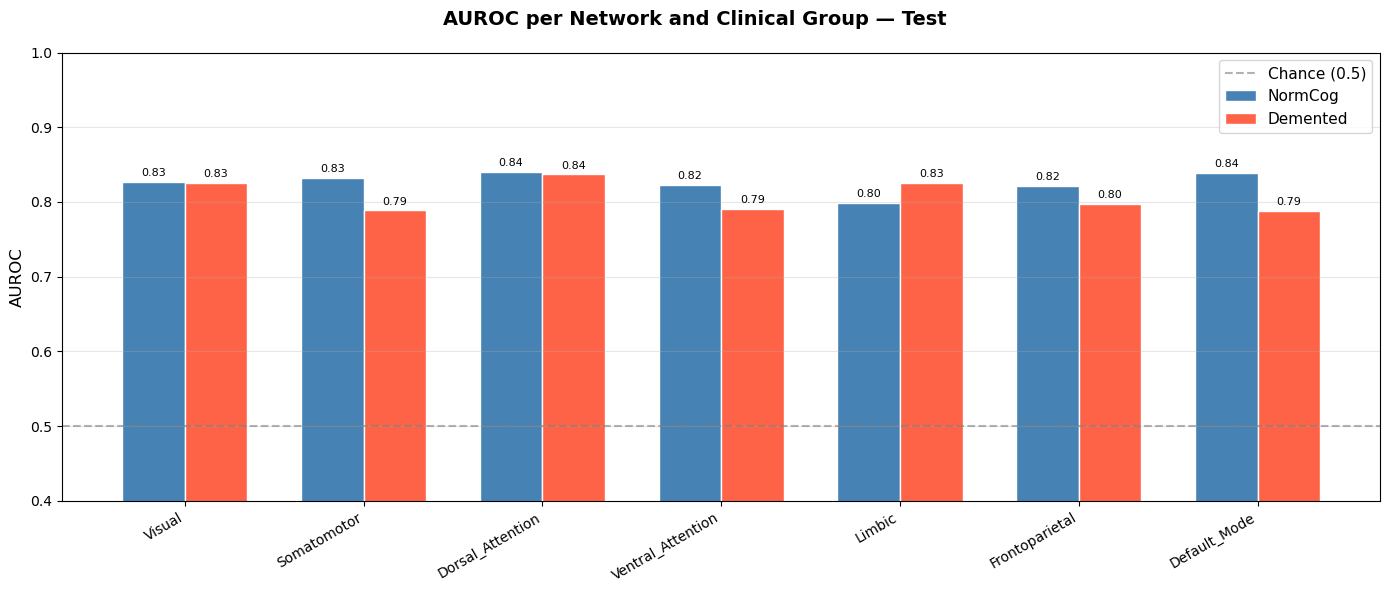

Figure saved: auroc_by_group.png


In [14]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('AUROC per Network and Clinical Group — Test', fontsize=14, fontweight='bold')

pivot = group_df.pivot(index='Red', columns='Grupo', values='AUROC')
# Keep original network order
pivot = pivot.reindex(NETWORK_NAMES)

x     = np.arange(N_NETWORKS)
width = 0.35

bars_norm = ax.bar(
    x - width/2,
    pivot.get('NormCog', np.zeros(N_NETWORKS)),
    width, label='NormCog', color='steelblue', edgecolor='white'
)
bars_dem = ax.bar(
    x + width/2,
    pivot.get('Demented', np.zeros(N_NETWORKS)),
    width, label='Demented', color='tomato', edgecolor='white'
)

ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Chance (0.5)')
ax.set_xticks(x)
ax.set_xticklabels(NETWORK_NAMES, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('AUROC', fontsize=12)
ax.set_ylim([0.4, 1.0])
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Annotate values
for bars in [bars_norm, bars_dem]:
    for bar in bars:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                    f'{h:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
print('Figure saved: auroc_by_group.png')

## 12. Final summary

In [15]:
print('='*60)
print('SUMMARY — LSTM BASELINE')
print('='*60)
print(f'Architecture     : LSTM (hidden=64, layers=2, dropout=0.3)')
print(f'Epochs           : {N_EPOCHS} (mejor: {best_epoch})')
print(f'Test Loss        : {test_loss:.4f}')
print(f'Test Hamming Acc : {test_hacc:.4f}')
print(f'Mean AUROC       : {metrics_df["AUROC"].mean():.4f}')
print(f'Mean AUPRC       : {metrics_df["AUPRC"].mean():.4f}')
print()
print('AUROC per network:')
for _, row in metrics_df.iterrows():
    bar = '█' * int(row['AUROC'] * 20)
    print(f'  {row["Red"]:<22} {bar:<20} {row["AUROC"]:.3f}')
print()
if len(group_df) > 0:
    print('AUROC medio por grupo:')
    for group, val in group_df.groupby('Grupo')['AUROC'].mean().items():
        print(f'  {group:<12}: {val:.4f}')
print('='*60)

SUMMARY — LSTM BASELINE
Architecture     : LSTM (hidden=64, layers=2, dropout=0.3)
Epochs           : 30 (mejor: 30)
Test Loss        : 0.8957
Test Hamming Acc : 0.8819
Mean AUROC       : 0.8225
Mean AUPRC       : 0.4254

AUROC per network:
  Visual                 ████████████████     0.827
  Somatomotor            ████████████████     0.825
  Dorsal_Attention       ████████████████     0.840
  Ventral_Attention      ████████████████     0.817
  Limbic                 ████████████████     0.803
  Frontoparietal         ████████████████     0.817
  Default_Mode           ████████████████     0.829

AUROC medio por grupo:
  Demented    : 0.8075
  NormCog     : 0.8259
